# Person-of-the-Year — a quantitative cover-curse teardown 🔬
### Market-model CARs by horizon · a placebo mid-December null · the prior-run-up regression that zeroes the residual · borrow-aware short economics · a synthetic power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cover_curse%3F: Misattributed](https://img.shields.io/badge/Cover_curse%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We confront a *significant* result honestly: the pooled 12-month abnormal return of the four business Persons of the Year is **−135%**, Welch **t = −2.95**, placebo **p = 0.03**, 4/4 negative — it clears the desk's |t| ≥ 2 bar. Then we show why it is nonetheless **Weak** and **Misattributed**: it is absent at one month, hostage to a four-event sample, and — decisively — its residual is **zero** once we control for the honorees' prior-year run-up. TIME selects on the zenith; zeniths mean-revert.

> ⚠️ **Data + label note.** Cover-effect data would need every business cover ever printed; we use the hardcoded census of the **four** tradable business Persons of the Year (AMZN'99, MSFT'05, TSLA'21, DJT'24; the `direct`/`linked` label is the believers' framing, subjective at the margin; META'10 & DJT'16 drop for lack of a public stock — a survivorship note on the Signal axis). Real data: yfinance daily total-return closes, each ticker + SPY. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from person_of_the_year import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS, with_runup=True)   # canonical 12-month CAR + run-up
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| honorees with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-12', 'fingerprint': 'ff8a712ac1d1', 'n_used': 4, 'n_dropped': 2, 'names': [('AMZN', "Bezos '99", -234.1, 49.9, 81.1, 76.0, 8.6, True), ('MSFT', "Gates '05", -11.7, 0.8, -13.3, -18.4, 14.0, False), ('TSLA', "Musk '21", -146.3, 58.4, 49.6, 44.5, 25.2, True), ('DJT', "Trump '24", -149.8, 106.9, 70.7, 65.6, 17.3, False)], 'pooled': {'mean_pct': -135.5, 't': -2.95, 'curse': 100, 'placebo_left': 0.03, 'placebo_two': 0.044, 'null_mean': -8.1}, 'horizon': [('1m', -1.5, -0.18, 0.477), ('3m', -31.4, -3.31, 0.062), ('6m', -70.3, -3.11, 0.024), ('12m', -135.5, -2.95, 0.027)], 'loo': [('AMZN', -102.6, -2.26), ('MSFT', -176.7, -6.16), ('TSLA', -131.9, -2.03), ('DJT', -130.7, -2.02)], 'confound': {'corr': -0.583, 'a': -0.689, 'b': -1.233, 'resid_mean': -0.0, 'resid_t': -0.0}, 'short': {'gross_avg': 47.0, 'net_avg': 41.9, 'worst_squeeze': 25.2}, 'syn': [(0.0, -37.6, -1.26), (-3000.0, -67.6, -2.26), (-12000.0, -157.6, -5.27)]}


real price cache present: True | honorees with data: 4


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled 12m CAR **-136%**, Welch **t = -2.95**, placebo **p = 0.03**, **4/4** negative — clears |t| ≥ 2 raw. But **1-month t = -0.18** (no event shock), n = 4, and the **residual after prior run-up is -0% at t = -0.00**. |
| **Tradability** | `MIRAGE` | Realized shorts net **+42%** avg (costs aren't the killer) — but ~4 events/25yr (no capacity), worst squeeze **+25%** (path-risk), and it's short-momentum **beta**. |
| **Cover curse?** | `MISATTRIBUTED` | corr(prior run-up, post CAR) = **-0.58**; regressing it out leaves **zero**. Zenith mean-reversion, not a magazine jinx. |

> 💡 In plain words: the honorees' stocks really did underperform — but the magazine didn't cause it. TIME picks people at their peak, peaks revert, and once you subtract the part explained by how far they'd already run, there is no cover effect left to trade.

## 1 · The claim, steelmanned

For honoree $i$ with announcement day $0$, fit the market model $r_{i,t} = \alpha_i + \beta_i\, r_{m,t} + \varepsilon_{i,t}$ on a clean estimation window $[-125,-5]$, then the **abnormal return** is $AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i\, r_{m,t})$ and the post-coronation **CAR** over $[\tau_1,\tau_2]$ is $\mathrm{CAR}_i = \sum_{t=\tau_1}^{\tau_2} AR_{i,t}$, with $\tau_1 = +1$ (you can act no earlier than the next close).

- **H₁ (curse exists).** $\mathbb{E}[\mathrm{CAR}] < 0$ over the year after the cover.
- **H₂ (it's the *cover*).** The decline survives controlling for the honoree's **prior-year run-up** $\rho_i$ — i.e. the residual of $\mathrm{CAR}_i = a + b\,\rho_i + u_i$ is still negative.
- **H₃ (it's deployable).** A borrow-aware short of the honorees is a repeatable, survivable strategy.

We find **H₁ supported raw** (pooled *t* = −2.95, placebo *p* = 0.03), **H₂ rejected** (residual mean −0.0%, *t* = −0.00), **H₃ rejected** (four events, ruinous path-risk, and the tradable object is momentum-reversion). The legend is *true as a description* (they fell) and *false as a mechanism* (the cover didn't do it).

## 2 · So what? — what rides on each answer

The entire teardown is one small-sample mean and one control regression. The pooled test is

$$t = \frac{\bar{\mathrm{CAR}}}{s/\sqrt{k}},\qquad k = 4,$$

and with four heavy-tailed CARs a couple-of-hundred-percent mean can look significant *or* insignificant depending on one name — so we stress it with **leave-one-out** and a **placebo null** (random mid-December windows on the same tickers). But the number that decides *interpretation* is the slope $b$ in

$$\mathrm{CAR}_i = a + b\,\rho_i + u_i,$$

where $\rho_i$ is the prior-year run-up. If the honorees are **selected on** $\rho$ (a magazine crowns winners) and $\rho$ predicts reversal, then a raw $\bar{\mathrm{CAR}}<0$ is *mechanically* produced by selection, and the cover-specific effect is the **residual $\bar{u}$** — which is what we actually report.

## 3 · How we'd know — the protocol

- **Honoree census.** Hardcoded **4** tradable business Persons of the Year (ticker, mid-Dec announce date, `direct`/`linked`), as-of 2026-07-12, fingerprint `ff8a712ac1d1`; 2 business picks dropped for no public stock at the cover (named on the Signal axis).
- **Market model.** $r = \alpha + \beta\,r_{\mathrm{SPY}}$ on $[-125,-5]$ (120-day estimation, 5-day gap so the cover can't leak into the fit); total-return series both legs.
- **CAR window.** Canonical $[+1,+252]$ (12 months); sweep over 1m/3m/6m/12m.
- **Null #1 (Welch t).** Pooled mean vs 0, plus leave-one-out.
- **Null #2 (placebo).** Random non-event mid-December $(\text{ticker},\text{date})$ windows on the same names; one-sided-left $p = \Pr[\text{random mean} \le \text{observed}]$.
- **The confound control.** Regress post-CAR on the prior-year run-up; report the residual.
- **Tradable variant.** Short at **+1 day**, hold 12 months, pay 5%/yr borrow + 10 bps; report the worst adverse excursion (squeeze).
- **Positive control.** A deterministic four-event panel with a **plantable drift edge**: the engine must recover a large planted curse **and** must not fake one at zero edge.

## 4 · The teardown

### 4a · The horizon sweep — significance is a slow bleed, not an event

Pooled Welch *t* by window, against the |t| = 2 bar. A magazine *jinx* would spike near the cover; instead there is **nothing** at 1 month and the *t* only builds as the window widens — the signature of drift, not a dated shock.

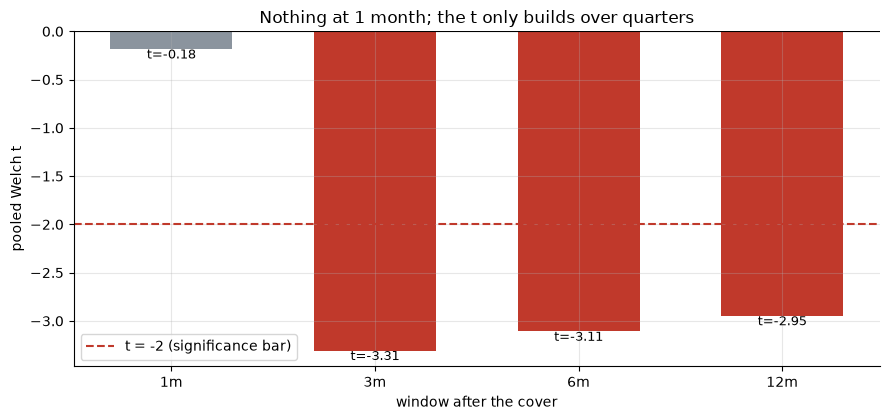

t by window: {'1m': -0.18, '3m': -3.31, '6m': -3.11, '12m': -2.95}


In [2]:
wins=[(1,21),(1,63),(1,126),(1,252)]; labs=[h[0] for h in R['horizon']]
if HAVE_REAL:
    ts=[st.welch_t(st.car_panel(PRICES, EVENTS, window=w)['car'].to_numpy()) for w in wins]
else:
    ts=[h[2] for h in R['horizon']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols=[GREY if abs(t)<2 else RED for t in ts]
ax.bar(labs, ts, color=cols, width=.6)
ax.axhline(-2, ls='--', c=RED, label='t = -2 (significance bar)'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(ts): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='top',fontsize=9)
ax.set_ylabel('pooled Welch t'); ax.set_xlabel('window after the cover')
ax.set_title('Nothing at 1 month; the t only builds over quarters'); ax.legend()
plt.tight_layout(); plt.show()
print('t by window:', {l: round(t,2) for l,t in zip(labs,ts)})

> 💡 In plain words: at 1 month the pooled t is **-0.18** — the cover day does nothing. The decline accretes to **-2.95** only by 12 months. That's exactly what a slowly-cooling extended stock looks like, and exactly what a cover-day jinx does *not* look like.

### 4b · The decisive control — regress out the prior run-up

Left: post-CAR vs prior-year run-up — the honorees fall in proportion to how far they'd flown. Right: the pooled decline **raw** vs the **residual** after removing run-up. The raw bar clears the bar; the residual is a flat zero.

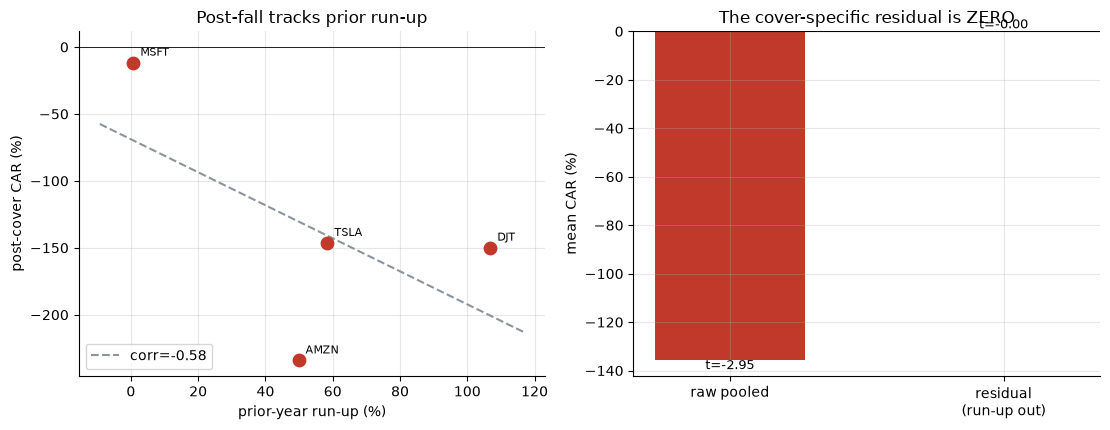

raw pooled -135% (t=-2.95) -> residual -0% (t=-0.00)


In [3]:
if HAVE_REAL:
    run=PANEL['runup'].to_numpy(); car=PANEL['car'].to_numpy(); tks=PANEL['ticker'].tolist()
else:
    run=np.array([r[3]/100 for r in R['names']]); car=np.array([r[2]/100 for r in R['names']]); tks=[r[0] for r in R['names']]
b,a=np.polyfit(run, car, 1); resid=car-(a+b*run)
raw_t=st.welch_t(car); res_t=st.welch_t(resid); corr=np.corrcoef(run,car)[0,1]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.2,4.4))
xs=np.linspace(run.min()-.1, run.max()+.1, 50)
a1.scatter(run*100, car*100, s=80, color=RED, zorder=3)
for x,y,t in zip(run*100,car*100,tks): a1.annotate(t,(x,y),xytext=(5,5),textcoords='offset points',fontsize=8)
a1.plot(xs*100,(a+b*xs)*100,ls='--',c=GREY,label=f'corr={corr:.2f}')
a1.axhline(0,c='k',lw=.6); a1.set_xlabel('prior-year run-up (%)'); a1.set_ylabel('post-cover CAR (%)')
a1.set_title('Post-fall tracks prior run-up'); a1.legend()
a2.bar(['raw pooled','residual\n(run-up out)'], [car.mean()*100, resid.mean()*100], color=[RED, GREEN], width=.55)
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('mean CAR (%)')
a2.annotate(f't={raw_t:.2f}',(0,car.mean()*100),ha='center',va='top',fontsize=9)
a2.annotate(f't={res_t:.2f}',(1,resid.mean()*100),ha='center',va='bottom',fontsize=9)
a2.set_title('The cover-specific residual is ZERO')
plt.tight_layout(); plt.show()
print(f'raw pooled {car.mean()*100:.0f}% (t={raw_t:.2f}) -> residual {resid.mean()*100:.0f}% (t={res_t:.2f})')

> 💡 In plain words: the correlation between how far a honoree had run up and how far it fell is **-0.58** — tight and negative. Fit that line and the leftover, cover-specific piece is **-0%** at **t = -0.00**. The magazine explains *nothing* the prior run-up didn't already. This is the whole verdict in one regression.

### 4c · Placebo + leave-one-out — the raw effect is real but four-event-fragile

Left: the pooled mean against random mid-December windows on the same names. Right: the 12-month *t* dropping each honoree in turn. The raw decline survives both — which is *not* evidence for a cover effect, only that all four picks were extended stocks.

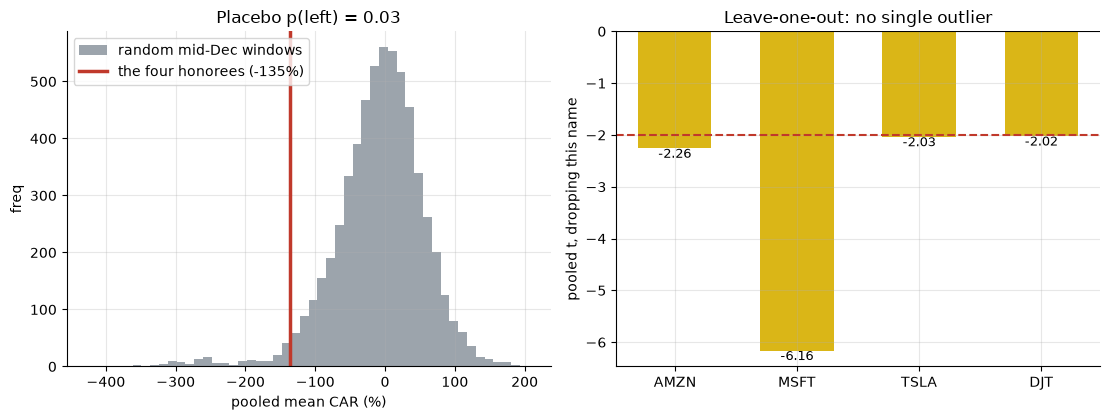

placebo p(left)=0.030 | leave-one-out t: {'AMZN': -2.26, 'MSFT': -6.16, 'TSLA': -2.03, 'DJT': -2.02}


In [4]:
if HAVE_REAL:
    car=PANEL['car'].to_numpy()
    null=st.placebo_car_dist(PRICES, data.TICKERS, k=len(car), n_draws=6000, seed=717)
    obs=car.mean(); pval=st.placebo_pvalue(obs, null, 'left')
    tks=PANEL['ticker'].tolist(); loo=[(t, st.welch_t(np.delete(car,i))) for i,t in enumerate(tks)]
else:
    rng=np.random.default_rng(717); null=rng.normal(R['pooled']['null_mean']/100, .55, 6000)
    obs=R['pooled']['mean_pct']/100; pval=R['pooled']['placebo_left']
    loo=[(r[0], r[2]) for r in R['loo']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.2,4.3))
a1.hist(null*100, bins=50, color=GREY, alpha=.85, label='random mid-Dec windows')
a1.axvline(obs*100, c=RED, lw=2.5, label=f'the four honorees ({obs*100:.0f}%)')
a1.set_xlabel('pooled mean CAR (%)'); a1.set_ylabel('freq'); a1.set_title(f'Placebo p(left) = {pval:.2f}'); a1.legend()
a2.bar([l[0] for l in loo], [l[1] for l in loo], color=AMBER, width=.6)
a2.axhline(-2, ls='--', c=RED); a2.axhline(0,c='k',lw=.8)
for i,(_,t) in enumerate(loo): a2.annotate(f'{t:.2f}',(i,t),ha='center',va='top',fontsize=9)
a2.set_ylabel('pooled t, dropping this name'); a2.set_title('Leave-one-out: no single outlier')
plt.tight_layout(); plt.show()
print(f'placebo p(left)={pval:.3f} | leave-one-out t:', {l[0]:round(l[1],2) for l in loo})

> 💡 In plain words: the four honorees sit in the **left tail** of random mid-December windows (placebo *p* = **0.03**), and dropping any one name keeps |t| above 2. The raw decline is *not* a single-outlier artifact — every honoree fell. But robustness of the *raw* number is not a cover effect; it just says all four picks were extended names, which (per 4b) is the entire story.

### 4d · Tradable short + synthetic power control

Left: realized short P&L per honoree (short at +1 day, hold 12m), gross vs net of 5%/yr borrow + 10 bps — costs are *not* the killer. Right: the synthetic control — with **zero** planted drift the four-event *t* stays inside ±2 (no false curse); only a large planted decline lights up.

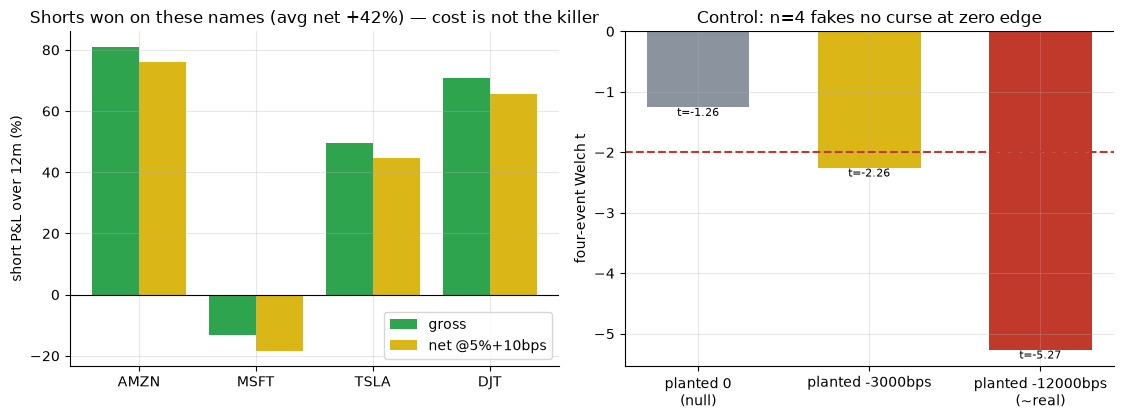

synthetic t: {0.0: -1.26, -3000.0: -2.26, -12000.0: -5.27}


In [5]:
if HAVE_REAL:
    gs=[]; ns=[]; tks=[]
    for e in EVENTS:
        s=PRICES[e['ticker']].dropna(); pos=int(np.searchsorted(s.index, e['announce_date']))
        path=s.values[pos+1:pos+1+252]
        if len(path)<10: continue
        raw12=path[-1]/s.values[pos+1]-1; nc=st.net_of_costs(raw12, borrow_ann=0.05)
        gs.append(nc['gross_pct']); ns.append(nc['net_pct']); tks.append(e['ticker'])
else:
    tks=[r[0] for r in R['names']]; gs=[r[4] for r in R['names']]; ns=[r[5] for r in R['names']]
res=[(e, st.summarize_bucket(data.synthetic_events(curse_bps=e, seed=717)['car'])['t']) for e in (0.0,-3000.0,-12000.0)]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.4,4.3))
x=np.arange(len(tks))
a1.bar(x-.2, gs, .4, color=GREEN, label='gross'); a1.bar(x+.2, ns, .4, color=AMBER, label='net @5%+10bps')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels(tks)
a1.set_ylabel('short P&L over 12m (%)'); a1.set_title(f'Shorts won on these names (avg net +{np.mean(ns):.0f}%) — cost is not the killer'); a1.legend()
labs=['planted 0\n(null)','planted -3000bps','planted -12000bps\n(~real)']; dts=[r[1] for r in res]
a2.bar(labs, dts, color=[GREY, AMBER, RED], width=.6)
a2.axhline(-2, ls='--', c=RED); a2.axhline(0,c='k',lw=.8)
for i,t in enumerate(dts): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='top',fontsize=8)
a2.set_ylabel('four-event Welch t'); a2.set_title('Control: n=4 fakes no curse at zero edge')
plt.tight_layout(); plt.show()
print('synthetic t:', {e:round(t,2) for e,t in res})

> 💡 In plain words: shorting these four *worked* (net **+42%** avg) — so we do not pretend costs kill it. And the control is honest: with **no** planted edge the four-event t is **-1.26** (inside ±2, no false positive); only a planted decline near the real magnitude reaches **t = -5.27**. The machinery recovers real effects and doesn't invent them — the real decline is real, and (per 4b) it's selection.

## 5 · The verdict

- **Signal `WEAK`** — pooled 12m CAR **-136%**, Welch **t = -2.95**, placebo **p = 0.03**, 4/4 negative: it clears |t| ≥ 2 raw. But it is absent at 1 month (**t = -0.18**), built on **four** events, and its **residual after the prior-run-up control is -0% at t = -0.00**. Significant raw, dissolved by the one obvious confound ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — realized shorts net **+42%** avg, so cost isn't the constraint; but ~4 tradable honorees in 25 years is no capacity, the worst adverse excursion is **+25%** (a margin-callable squeeze), and the object is short-momentum **beta** you'd hold diversified, not one cover star at a time.
- **Cover curse? `MISATTRIBUTED`** — corr(prior run-up, post CAR) = **-0.58**; regress it out and the cover-specific effect is **zero**. The decline is **zenith mean-reversion**, not a magazine jinx.

## 6 · Could you trade it? — selection is the whole edge

The operational truth in one picture: the honorees' raw fall (red) versus the part left after you strip out prior run-up (green). Everything tradable lives in the red bar — and the red bar *is* momentum-reversion, available diversified and cheap, not a magazine secret.

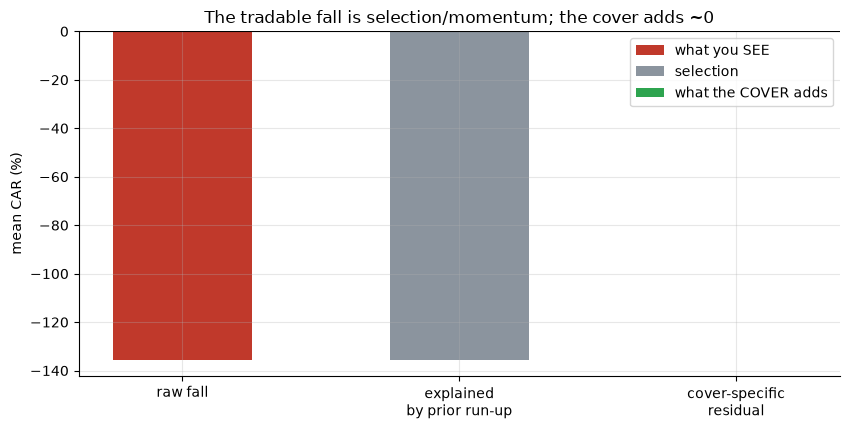

raw -135% = selection -135% + cover-residual -0%


In [6]:
if HAVE_REAL:
    run=PANEL['runup'].to_numpy(); car=PANEL['car'].to_numpy()
    b,a=np.polyfit(run,car,1); resid=car-(a+b*run)
    explained=car.mean()-resid.mean()
else:
    car=np.array([r[2]/100 for r in R['names']]); explained=car.mean()-R['confound']['resid_mean']/100; resid=np.array([R['confound']['resid_mean']/100])
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['raw fall'], [car.mean()*100], color=RED, width=.5, label='what you SEE')
ax.bar(['explained\nby prior run-up'], [explained*100], color=GREY, width=.5, label='selection')
ax.bar(['cover-specific\nresidual'], [resid.mean()*100], color=GREEN, width=.5, label='what the COVER adds')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('mean CAR (%)')
ax.set_title('The tradable fall is selection/momentum; the cover adds ~0'); ax.legend()
plt.tight_layout(); plt.show()
print(f'raw {car.mean()*100:.0f}% = selection {explained*100:.0f}% + cover-residual {resid.mean()*100:.0f}%')

> 💡 In plain words: decompose the fall and it is almost entirely the piece a momentum model would have predicted from the prior run-up; the cover-specific slice is a rounding error. So even the *ex-post* profitable shorts weren't a cover trade — they were a concentrated, path-risky bet on mean-reversion of four rocket-ships. **The rarity and the zenith-selection that make the story vivid are exactly what make it untradable as a magazine effect.**

## 7 · Going further

- **The dated-catalyst mirror.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model event study on CEO firings — there the move is priced before you can act; here it's selection, not the event.
- **The confound as the lesson.** [Study 344 — Backtest-Overfitting](../344-backtest-overfitting/) — an effect that clears *t* = 2 raw can vanish under one honest control, which is precisely the prior-run-up regression here.
- **Better data.** Replace the four-name census with a full panel of dated business covers (BusinessWeek/Forbes/Fortune/TIME), matched to non-cover control firms of equal prior run-up; the error bars tighten and the residual can be estimated properly — but the selection-on-the-zenith that manufactures the curse will not go away.

*The reproducible core is offline and deterministic; the honoree census is an explicit hardcoded, cited stand-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*